In [ ]:
Modelisation of MvTec image dataset by supervised Machine Learning

1) Predicted category names of all category objects
2) Predicted labels of all category objects
3) Predicted labels per category (Recommended)
4) Predicted defect types  per category (Recommended)

Used 4 models KNN, SVM, XGBoost and RF and compared results with and without oversampling
Used recall and confusion matrix as evaluation metrics

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from pathlib import Path
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from skimage.feature import hog
from skimage import feature,data, exposure

from scipy.stats import skew
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from imblearn.pipeline import Pipeline

In [49]:
# Use Modelisation_Part1_ImageProperties for dataset "mvtec_full_stats_features_colour_images"

def get_original_image(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    return img

def get_gray_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    img = img / 255.0
    return img
    
def get_pixel_mean(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.mean()
    
def get_pixel_std(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.std()

def get_pixel_min(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.min()

def get_pixel_max(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.max()

def get_pixel_median(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return np.median(img)

def get_hog_features(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (256, 256))
    imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog = feature.hog(imgGray, pixels_per_cell=(8,8),
                          cells_per_block=(2,2), visualize=False)
    return hog

    
def displayheatmap(cm):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,        # show numbers
        fmt="d",           # integer format
        cmap="Blues",      # color map
        cbar=False
    )
    
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")
    plt.show()


In [5]:
df= pd.read_pickle("mvtec_full_statistiques_features_colour_images.pkl")
print(df.shape)

(5354, 22)


In [4]:
df.head()

,file_path,category_name,dir_name,file_name,file_size,label,img,mean,mean_red,mean_green,...,std_red,std_green,std_blue,skew,skew_red,skew_green,skew_blue,img_min,img_max,img_median
0,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,000.png,526002,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,...","[138.37049865722656, 137.56890869140625, 142.0...",138.37,137.57,...,92.69,92.70,88.21,0.352307,0.326818,0.354181,0.389086,29,255,91.0
1,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,001.png,525657,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,...","[134.5216827392578, 133.90904235839844, 138.86...",134.52,133.91,...,93.86,93.87,89.07,0.396253,0.378514,0.398122,0.426304,25,255,86.0
2,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,002.png,515614,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,...","[135.526611328125, 135.02493286132812, 139.934...",135.53,135.02,...,92.78,92.81,88.15,0.406645,0.390658,0.407397,0.435852,29,255,85.0
3,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,003.png,488569,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,...","[133.0048370361328, 132.4598388671875, 137.540...",133.00,132.46,...,95.57,95.53,90.48,0.394503,0.376944,0.394516,0.427282,28,255,80.0
4,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,004.png,549987,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,...","[138.3481903076172, 137.09600830078125, 141.33...",138.35,137.10,...,92.53,92.58,87.98,0.358822,0.324502,0.362094,0.403420,29,255,91.0


KNN model - Train and predict
Accuracy of train data:  0.9248190520663087
Accuracy of test data:  0.8776844070961718
              precision    recall  f1-score   support

      bottle       0.97      0.98      0.97        58
       cable       0.73      0.76      0.75        75
     capsule       0.97      0.89      0.93        70
      carpet       1.00      1.00      1.00        80
        grid       0.89      0.82      0.85        68
    hazelnut       0.94      0.93      0.93       100
     leather       0.62      0.57      0.59        74
   metal_nut       0.82      0.90      0.86        67
        pill       1.00      0.98      0.99        87
       screw       0.95      0.90      0.92        96
        tile       0.91      0.90      0.91        70
  toothbrush       0.59      0.65      0.62        20
  transistor       0.85      0.95      0.90        63
        wood       0.80      0.82      0.81        65
      zipper       0.88      0.94      0.91        78

    accuracy     

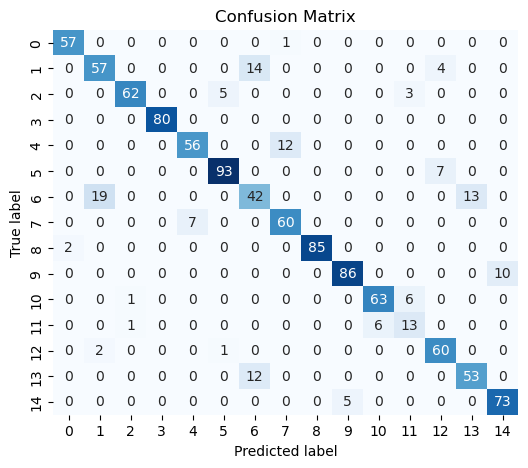

SVM model - Train and predict
Accuracy of train data:  0.7436376371702078
Accuracy of test data:  0.7329598506069094
              precision    recall  f1-score   support

      bottle       0.61      0.67      0.64        58
       cable       0.66      0.87      0.75        75
     capsule       0.90      0.93      0.92        70
      carpet       0.99      1.00      0.99        80
        grid       0.56      0.87      0.68        68
    hazelnut       0.82      0.99      0.90       100
     leather       0.69      0.30      0.42        74
   metal_nut       0.00      0.00      0.00        67
        pill       1.00      0.98      0.99        87
       screw       0.53      1.00      0.70        96
        tile       0.83      0.99      0.90        70
  toothbrush       0.00      0.00      0.00        20
  transistor       0.89      0.76      0.82        63
        wood       0.76      0.89      0.82        65
      zipper       0.00      0.00      0.00        78

    accuracy     

C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

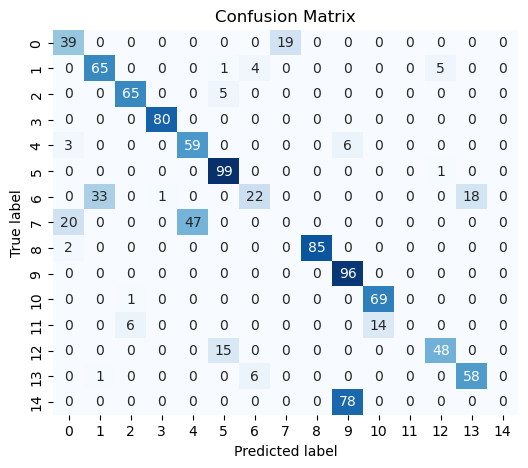

Creating Random forest model and train. Predict with test data
Accuracy of train data:  1.0
Accuracy of test data:  1.0
              precision    recall  f1-score   support

      bottle       1.00      1.00      1.00        52
       cable       1.00      1.00      1.00        59
     capsule       1.00      1.00      1.00        64
      carpet       1.00      1.00      1.00        75
        grid       1.00      1.00      1.00        55
    hazelnut       1.00      1.00      1.00        84
     leather       1.00      1.00      1.00        57
   metal_nut       1.00      1.00      1.00        63
        pill       1.00      1.00      1.00        96
       screw       1.00      1.00      1.00        96
        tile       1.00      1.00      1.00        61
  toothbrush       1.00      1.00      1.00        16
  transistor       1.00      1.00      1.00        45
        wood       1.00      1.00      1.00        60
      zipper       1.00      1.00      1.00        81

    accuracy  

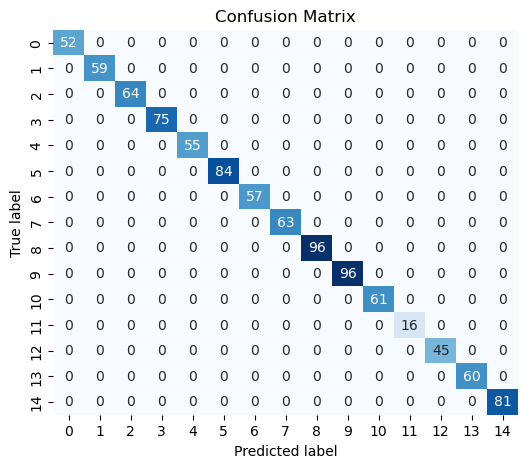

Significant features impacting prediction
file_size     0.151092
mean_blue     0.110857
mean_green    0.094082
img_median    0.093384
std_blue      0.090080
skew_red      0.079266
mean_red      0.076906
std_green     0.072536
std_red       0.066081
skew_green    0.064061
skew_blue     0.054545
img_min       0.036829
img_max       0.010280
dtype: float64


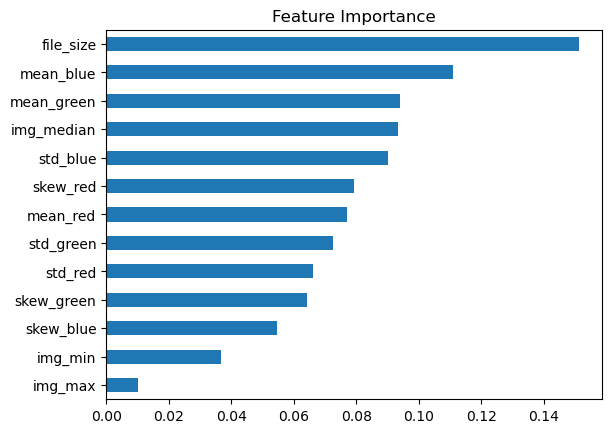

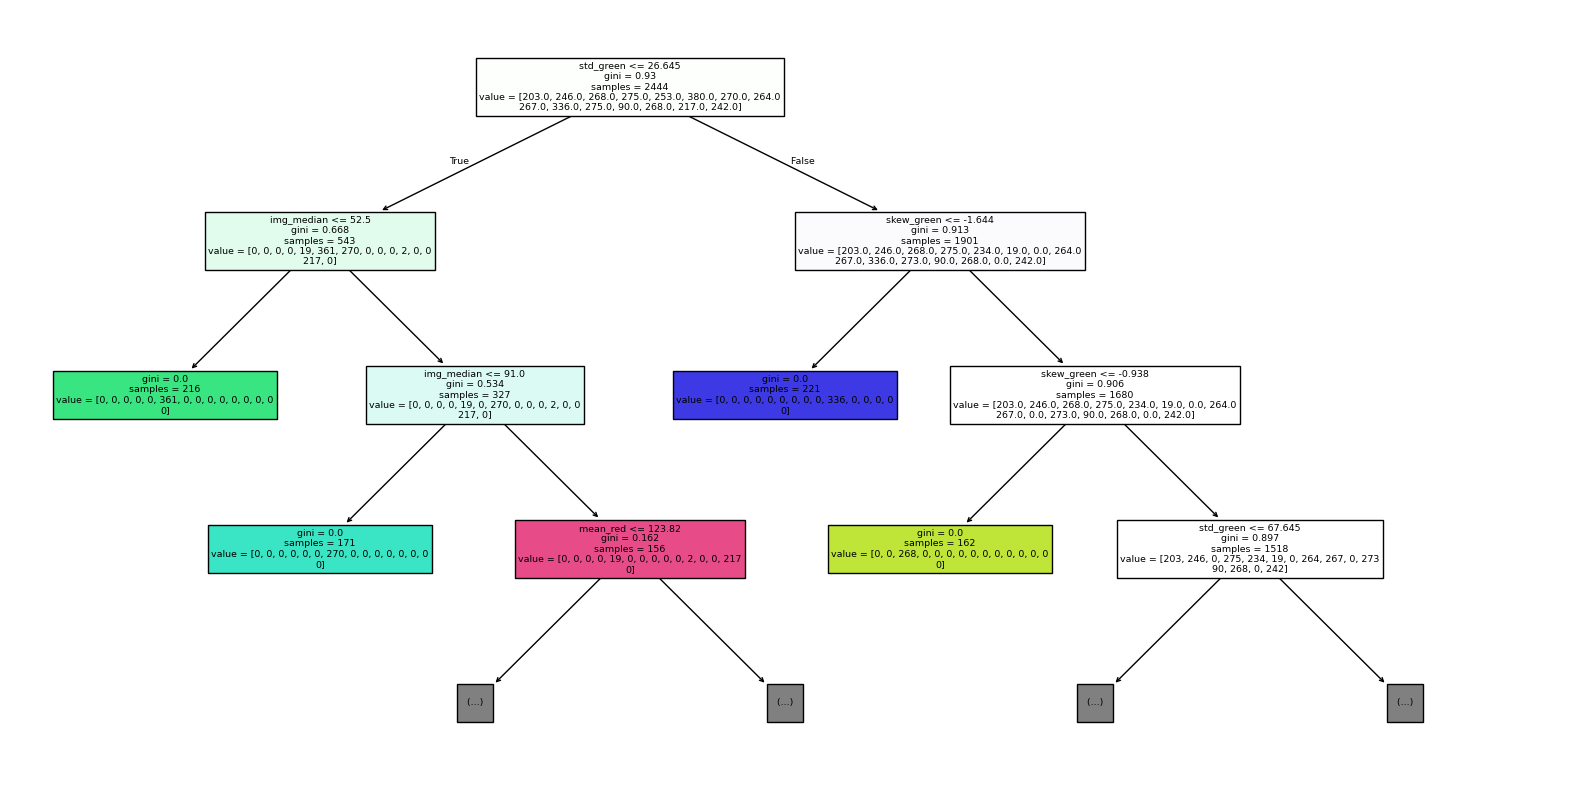

Using existing random forest model, predict with validation data
Accuracy of test data:  1.0
              precision    recall  f1-score   support

      bottle       1.00      1.00      1.00        25
       cable       1.00      1.00      1.00        42
     capsule       1.00      1.00      1.00        36
      carpet       1.00      1.00      1.00        41
        grid       1.00      1.00      1.00        31
    hazelnut       1.00      1.00      1.00        54
     leather       1.00      1.00      1.00        49
   metal_nut       1.00      1.00      1.00        32
        pill       1.00      1.00      1.00        41
       screw       1.00      1.00      1.00        39
        tile       1.00      1.00      1.00        33
  toothbrush       1.00      1.00      1.00         9
  transistor       1.00      1.00      1.00        35
        wood       1.00      1.00      1.00        26
      zipper       1.00      1.00      1.00        43

    accuracy                           1.

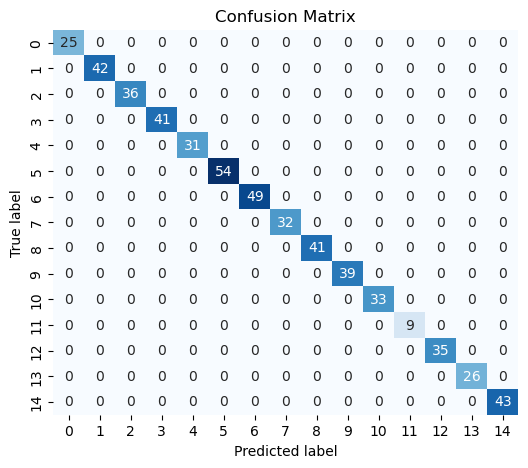

Significant features impacting prediction
file_size     0.151092
mean_blue     0.110857
mean_green    0.094082
img_median    0.093384
std_blue      0.090080
skew_red      0.079266
mean_red      0.076906
std_green     0.072536
std_red       0.066081
skew_green    0.064061
skew_blue     0.054545
img_min       0.036829
img_max       0.010280
dtype: float64


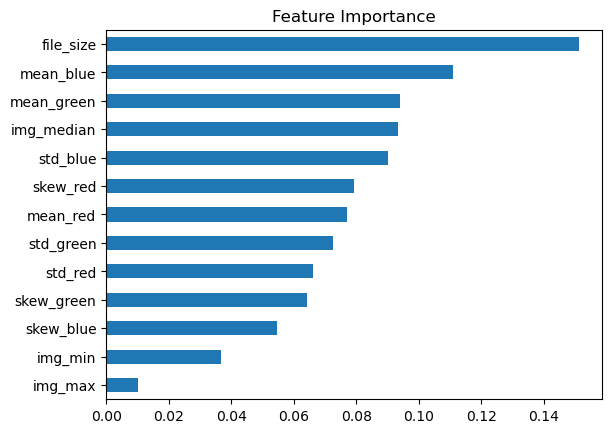

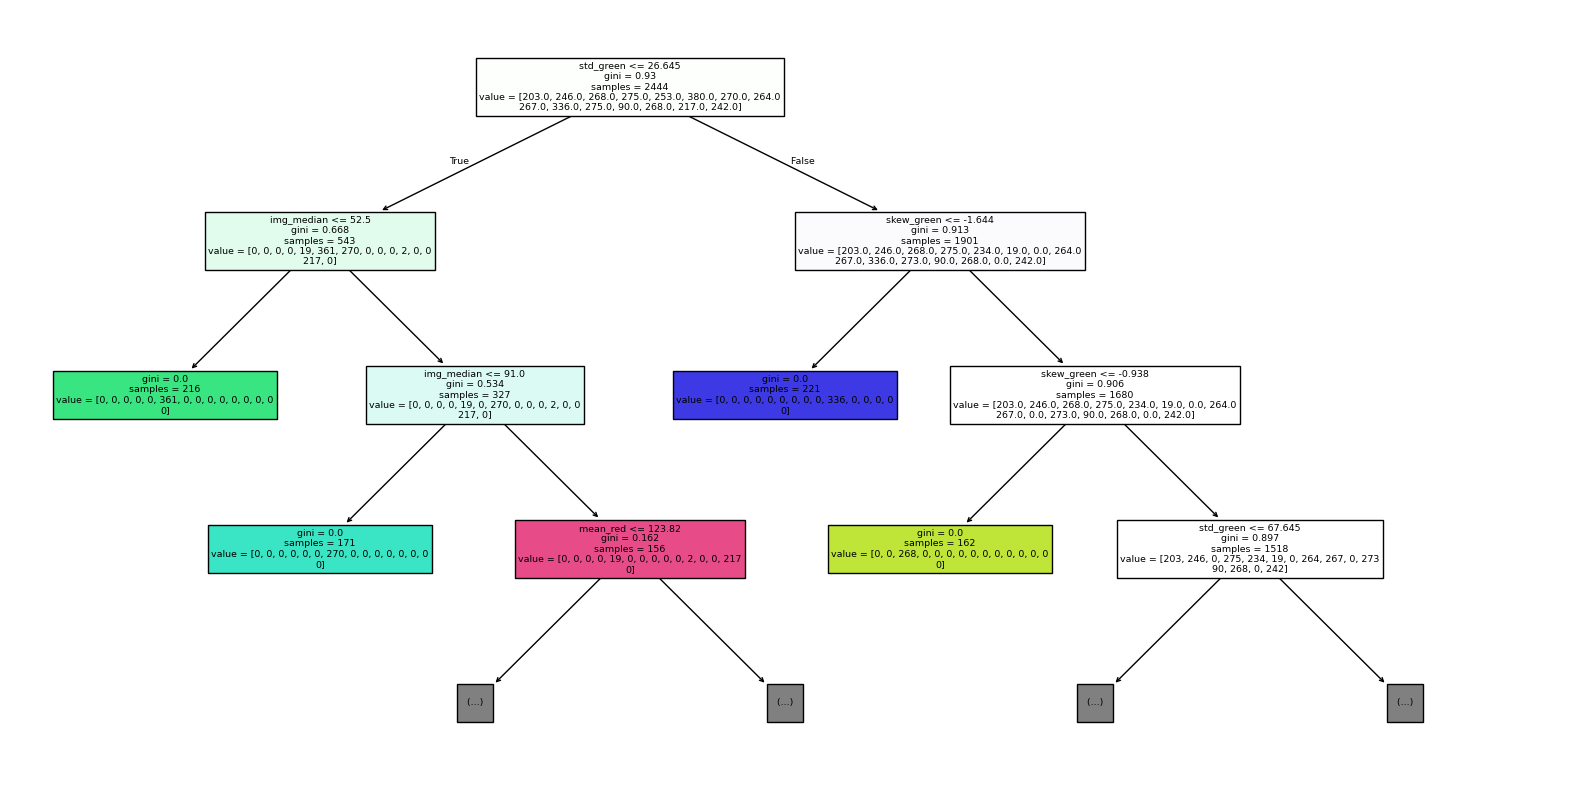

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# Predict category of objects of full MvTec dataset
# Use 3 models KNN, SVM et RF and compare results
# RF is best

X = df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y= df['category_name']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)
KNN_TrainAndPredict(X_train,y_train,X_test,y_test)
SVM_TrainAndPredict(X_train,y_train,X_test,y_test)

X, X_valid, y, y_valid = train_test_split(X, y, test_size=0.1 )

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf_output = RF_TrainAndPredict(None, X_train,y_train,X_test,y_test)
RF_TrainAndPredict(rf_output, X_train, y_train, X_valid, y_valid)

KNN model - Train and predict
Accuracy of train data:  0.8066775624562222
Accuracy of test data:  0.7236227824463118
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       819
           1       0.35      0.20      0.25       252

    accuracy                           0.72      1071
   macro avg       0.56      0.54      0.54      1071
weighted avg       0.68      0.72      0.69      1071



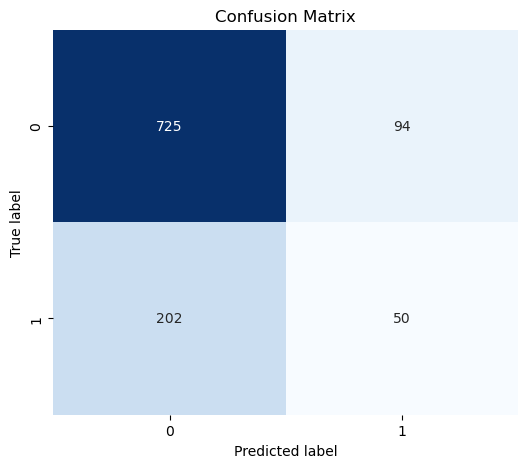

SVM model - Train and predict
Accuracy of train data:  0.7651179080084053
Accuracy of test data:  0.7647058823529411
              precision    recall  f1-score   support

           0       0.76      1.00      0.87       819
           1       0.00      0.00      0.00       252

    accuracy                           0.76      1071
   macro avg       0.38      0.50      0.43      1071
weighted avg       0.58      0.76      0.66      1071



C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

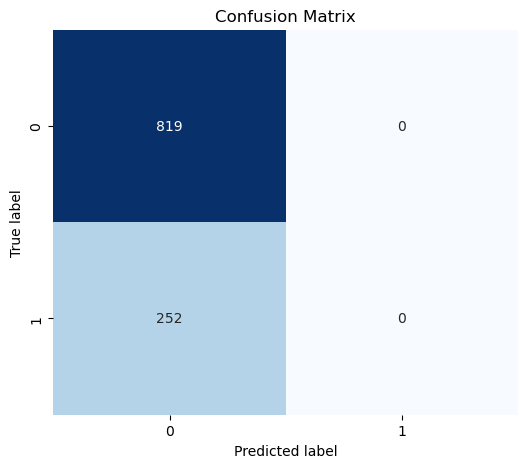

Creating Random forest model and train. Predict with test data
Accuracy of train data:  1.0
Accuracy of test data:  0.8900414937759336
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       755
           1       0.83      0.62      0.71       209

    accuracy                           0.89       964
   macro avg       0.87      0.79      0.82       964
weighted avg       0.89      0.89      0.88       964



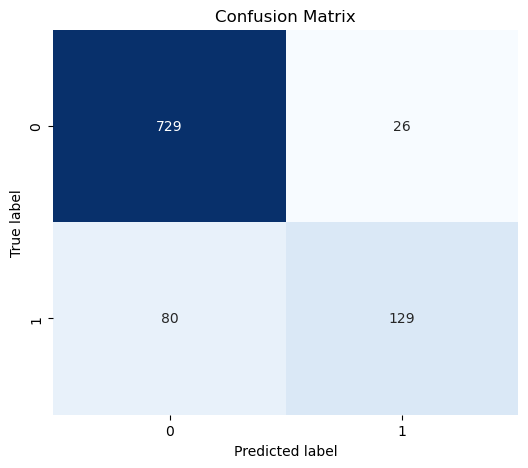

Significant features impacting prediction
img_min       0.092740
mean_blue     0.085541
std_blue      0.083550
file_size     0.082778
skew_blue     0.079314
mean_green    0.078006
skew_green    0.076195
mean_red      0.076091
std_green     0.072101
std_red       0.071131
img_median    0.069777
skew_red      0.068154
img_max       0.064622
dtype: float64


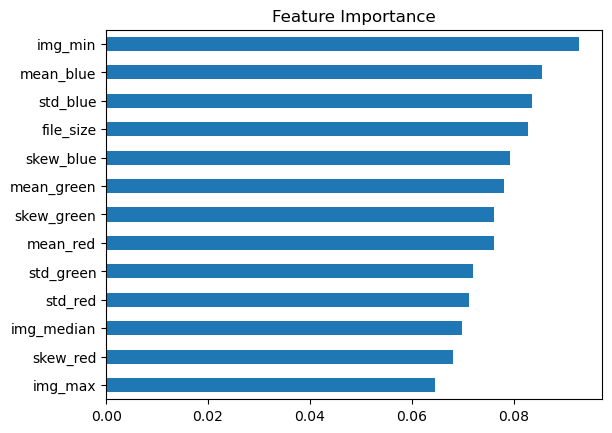

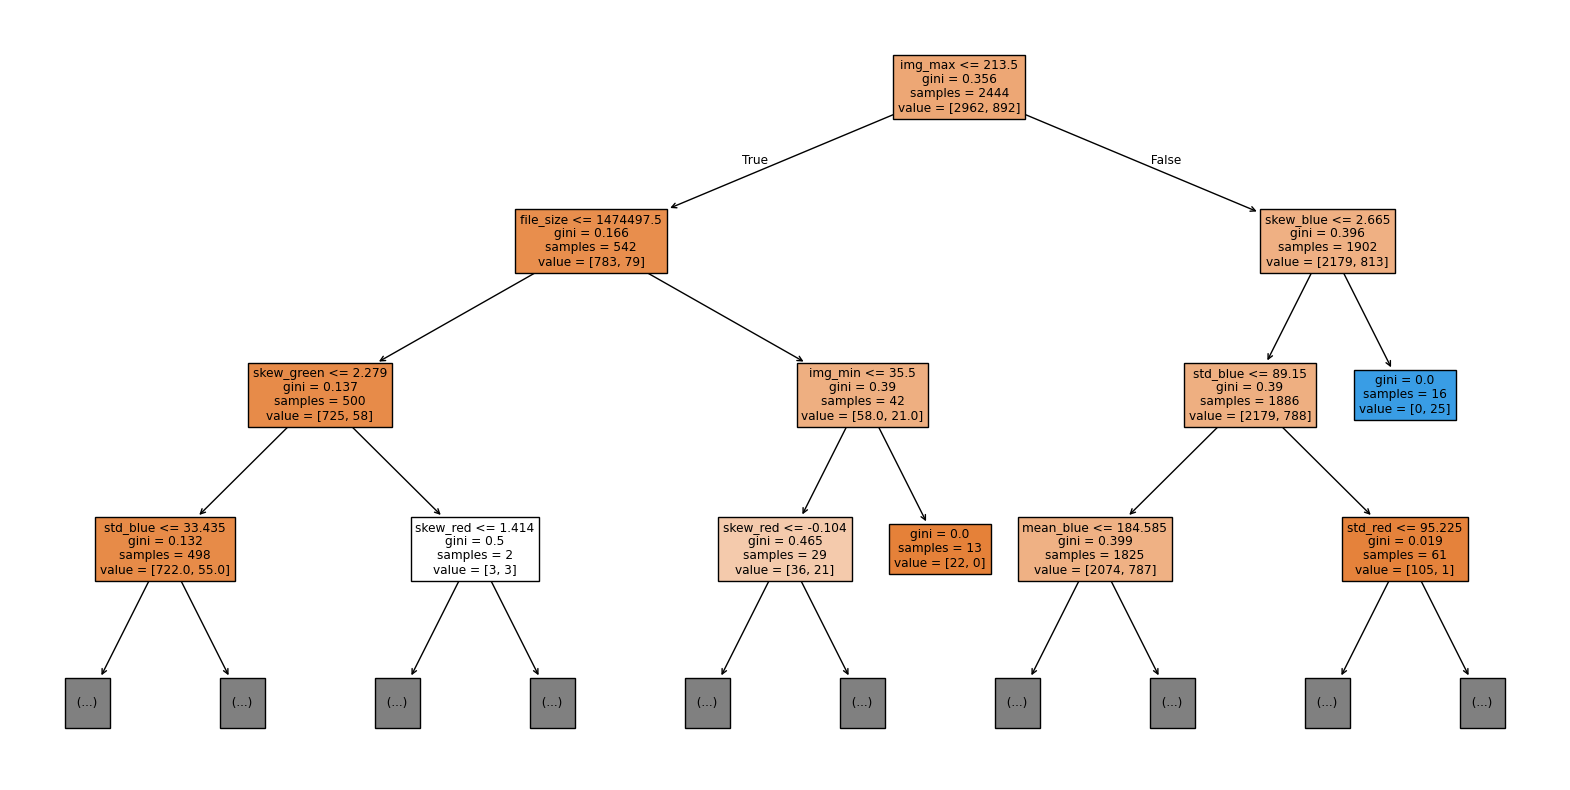

Using existing random forest model, predict with validation data
Accuracy of test data:  0.8861940298507462
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       390
           1       0.92      0.64      0.75       146

    accuracy                           0.89       536
   macro avg       0.90      0.81      0.84       536
weighted avg       0.89      0.89      0.88       536



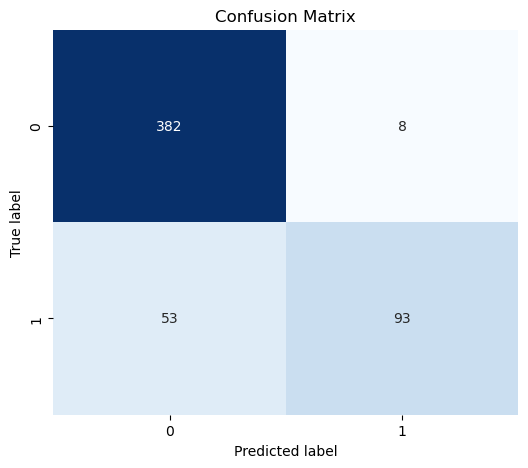

Significant features impacting prediction
img_min       0.092740
mean_blue     0.085541
std_blue      0.083550
file_size     0.082778
skew_blue     0.079314
mean_green    0.078006
skew_green    0.076195
mean_red      0.076091
std_green     0.072101
std_red       0.071131
img_median    0.069777
skew_red      0.068154
img_max       0.064622
dtype: float64


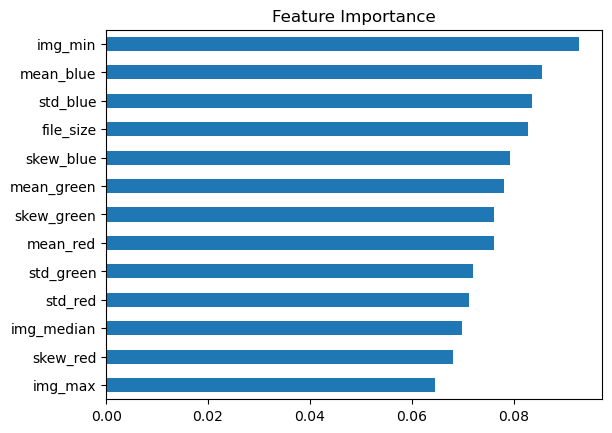

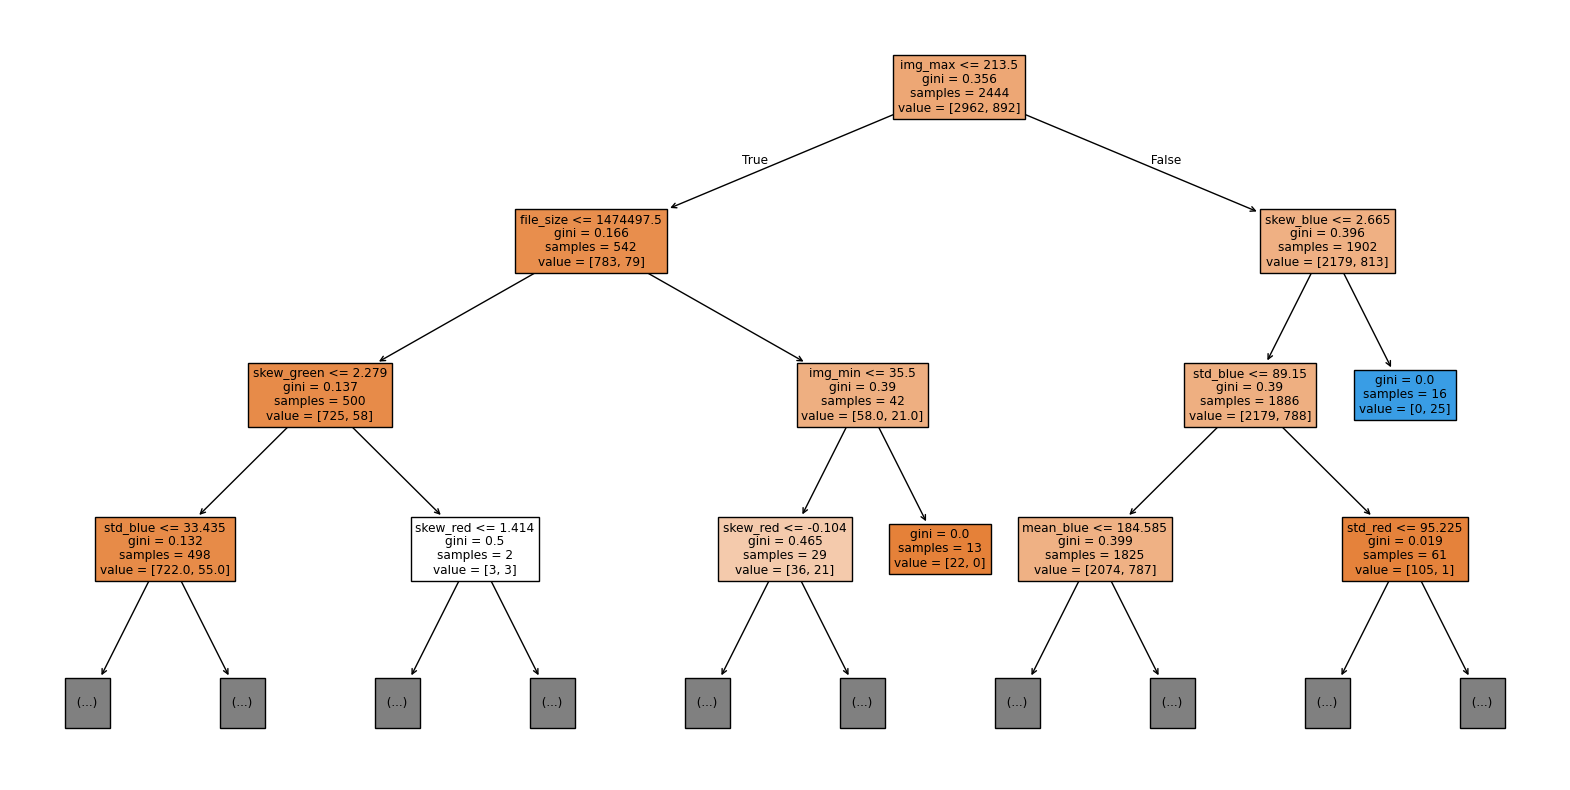

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
# Predict labels (good or anamoly) of objects of full MvTec dataset
# Use 3 models KNN, SVM et RF and compare results
# RF is best

X = df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y= df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)
KNN_TrainAndPredict(X_train,y_train,X_test,y_test)
SVM_TrainAndPredict(X_train,y_train,X_test,y_test)

X, X_valid, y, y_valid = train_test_split(X, y, test_size=0.1 )
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf_output = RF_TrainAndPredict(None, X_train,y_train,X_test,y_test)
RF_TrainAndPredict(rf_output, X_train, y_train, X_valid, y_valid)

KNN model - Train and predict
Accuracy of train data:  0.7642857142857142
Accuracy of test data:  0.647887323943662
              precision    recall  f1-score   support

           0       0.70      0.86      0.77        49
           1       0.36      0.18      0.24        22

    accuracy                           0.65        71
   macro avg       0.53      0.52      0.51        71
weighted avg       0.60      0.65      0.61        71



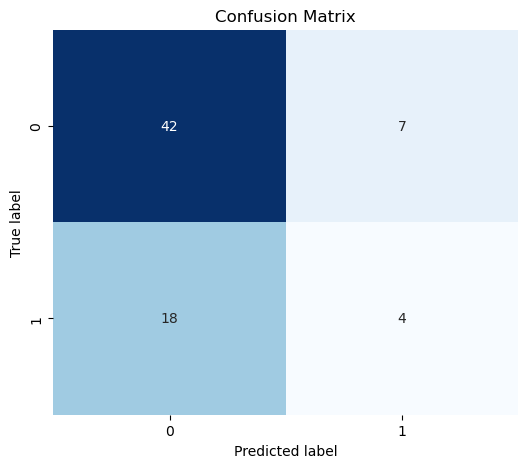

KNN model Oversampling - Train and Predict
Accuracy of train data:  1.0
Accuracy of test data:  0.8591549295774648
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        49
           1       0.77      0.77      0.77        22

    accuracy                           0.86        71
   macro avg       0.84      0.84      0.84        71
weighted avg       0.86      0.86      0.86        71



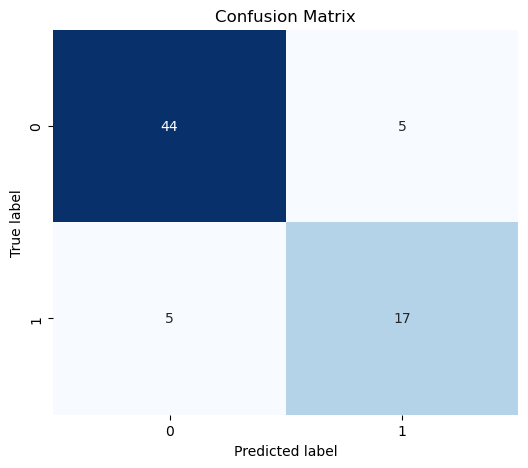

Creating Random forest model and train. Predict with test data
Accuracy of train data:  1.0
Accuracy of test data:  0.8873239436619719
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        49
           1       0.85      0.77      0.81        22

    accuracy                           0.89        71
   macro avg       0.88      0.86      0.86        71
weighted avg       0.89      0.89      0.89        71



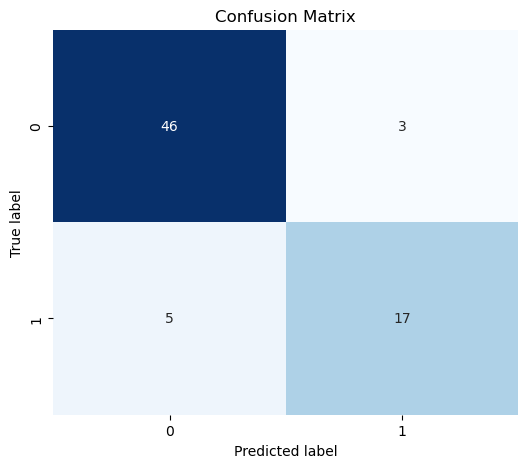

Significant features impacting prediction
img_min       0.154031
mean_blue     0.115880
mean_green    0.090895
mean_red      0.078378
skew_blue     0.076662
std_blue      0.072797
skew_green    0.068613
skew_red      0.065282
img_median    0.062819
std_green     0.061561
img_max       0.057371
std_red       0.054956
file_size     0.040755
dtype: float64


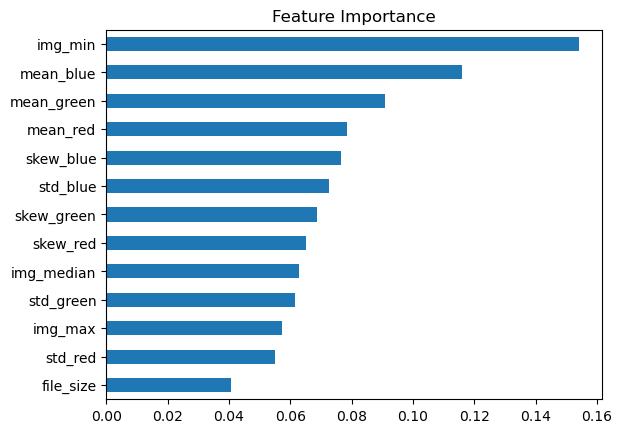

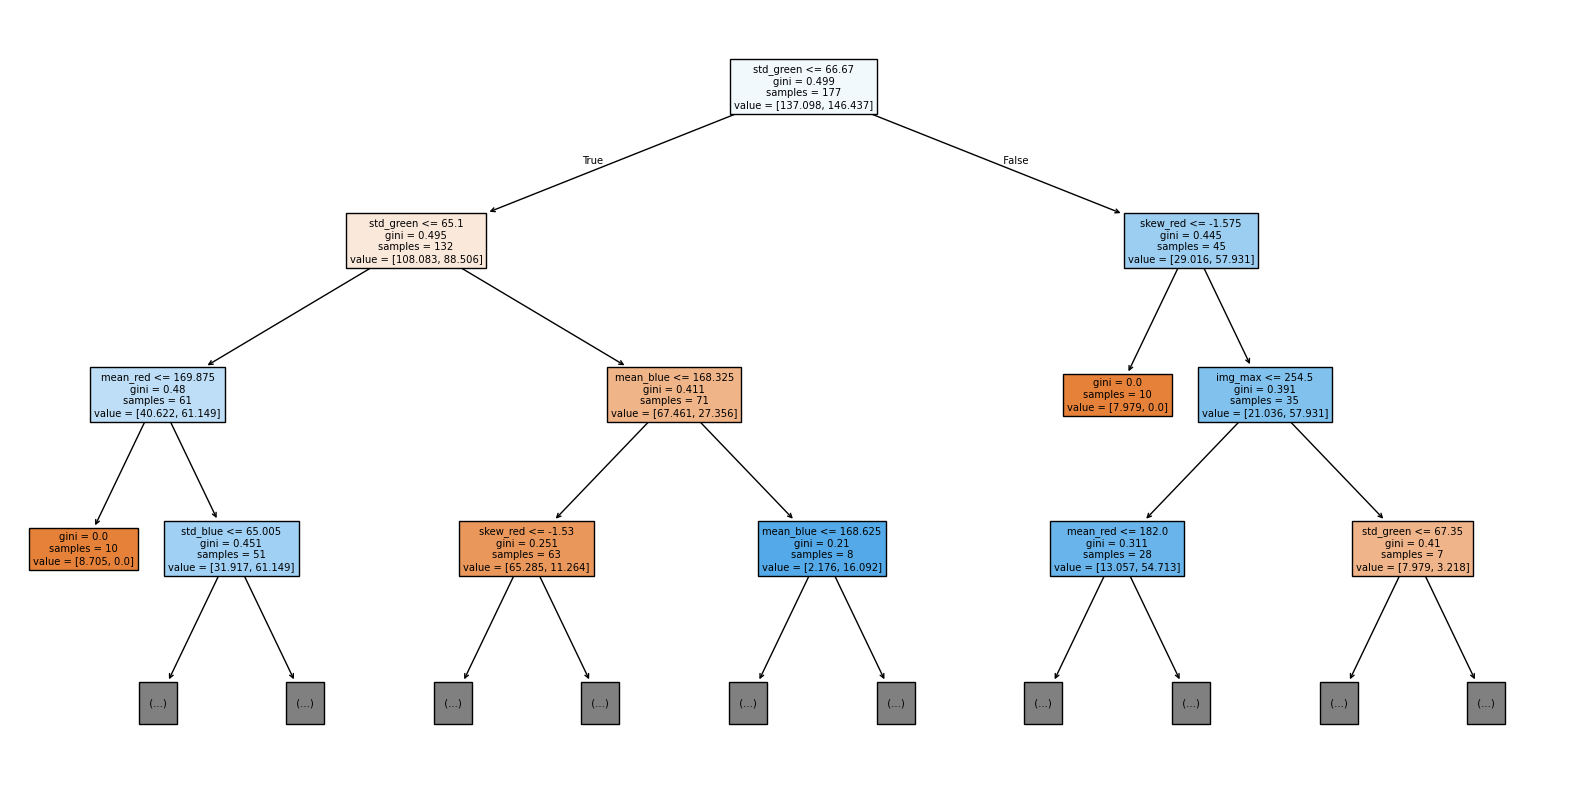

RF model Oversampling - Train and Predict
Accuracy of train data:  1.0
Accuracy of test data:  0.8732394366197183
              precision    recall  f1-score   support

           0       0.93      0.88      0.91        49
           1       0.76      0.86      0.81        22

    accuracy                           0.87        71
   macro avg       0.85      0.87      0.86        71
weighted avg       0.88      0.87      0.88        71



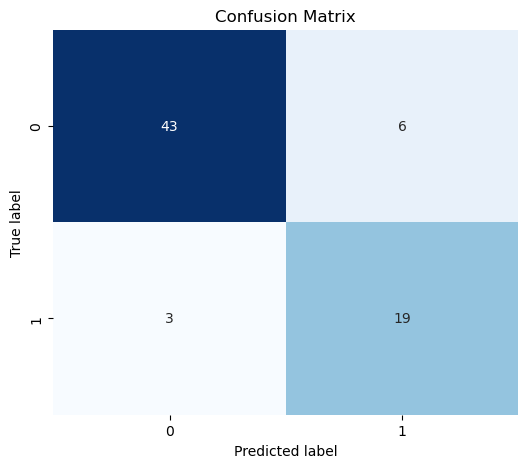

In [71]:
# Predict labels (good or anamoly) per category
# Use 2 models KNN et RF with oversampling (Compare with and without oversampling for 2 models)
# RF Oversampling is best

#df= pd.read_pickle("mvtec_full_statistiques_features_colour_images.pkl")
filtered_df = df[df["category_name"] == "capsule"]
#print(filtered_df.head(5))

X = filtered_df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y= filtered_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)

KNN_TrainAndPredict(X_train,y_train,X_test,y_test)
KNN_Oversampling_TrainAndPredict(X_train,y_train,X_test,y_test)
'''
X, X_valid, y, y_valid = train_test_split(X, y, test_size=0.1 )
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
'''
rf_output = RF_TrainAndPredict(None, X_train,y_train,X_test,y_test)
#RF_TrainAndPredict(rf_output, X_train, y_train, X_valid, y_valid)
RF_Oversampling_TrainAndPredict(X_train,y_train,X_test,y_test)

KNN model - Train and predict
Accuracy of train data:  0.7178571428571429
Accuracy of test data:  0.676056338028169
                precision    recall  f1-score   support

         crack       0.00      0.00      0.00         5
faulty_imprint       0.25      0.25      0.25         4
          good       0.70      0.96      0.81        49
          poke       0.00      0.00      0.00         4
       scratch       0.00      0.00      0.00         5
       squeeze       0.00      0.00      0.00         4

      accuracy                           0.68        71
     macro avg       0.16      0.20      0.18        71
  weighted avg       0.50      0.68      0.57        71



C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

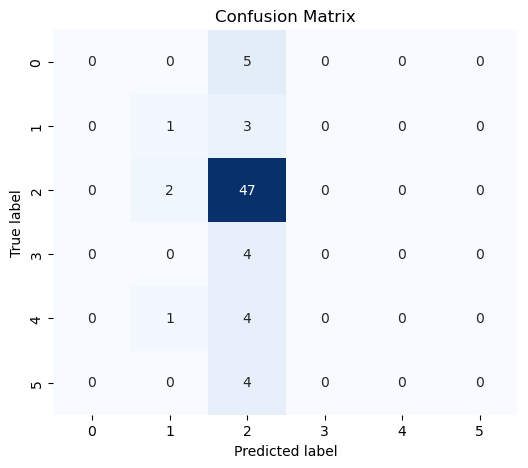

KNN model Oversampling - Train and Predict
Accuracy of train data:  1.0
Accuracy of test data:  0.4788732394366197
                precision    recall  f1-score   support

         crack       0.00      0.00      0.00         5
faulty_imprint       0.14      0.25      0.18         4
          good       0.90      0.57      0.70        49
          poke       0.17      0.25      0.20         4
       scratch       0.20      0.40      0.27         5
       squeeze       1.00      0.50      0.67         4

      accuracy                           0.48        71
     macro avg       0.40      0.33      0.34        71
  weighted avg       0.71      0.48      0.56        71



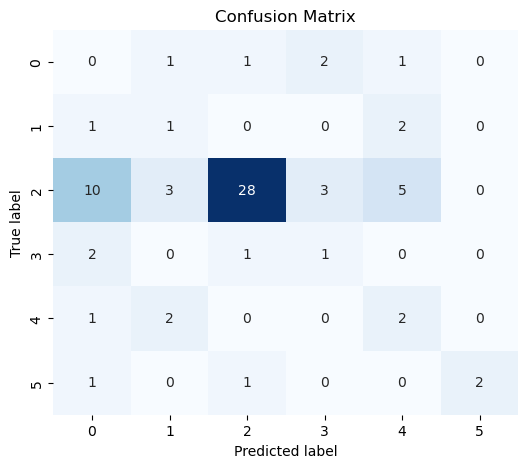

Creating Random forest model and train. Predict with test data
Accuracy of train data:  1.0
Accuracy of test data:  0.7323943661971831
                precision    recall  f1-score   support

         crack       0.00      0.00      0.00         5
faulty_imprint       0.00      0.00      0.00         4
          good       0.77      1.00      0.87        49
          poke       0.00      0.00      0.00         4
       scratch       0.50      0.20      0.29         5
       squeeze       1.00      0.50      0.67         4

      accuracy                           0.73        71
     macro avg       0.38      0.28      0.30        71
  weighted avg       0.62      0.73      0.66        71



C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

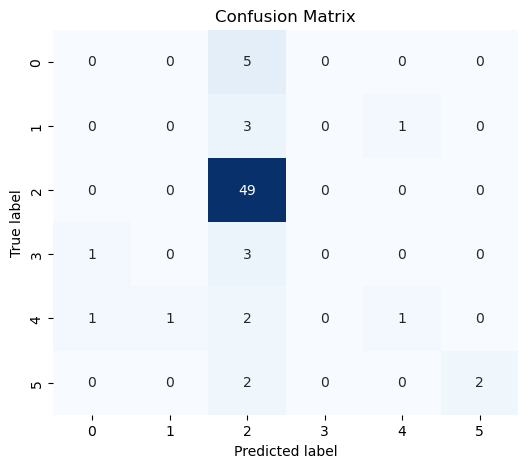

Significant features impacting prediction
skew_blue     0.122527
skew_green    0.116955
skew_red      0.098193
std_blue      0.085411
std_green     0.083544
mean_blue     0.073740
file_size     0.068887
std_red       0.064761
img_max       0.064397
mean_green    0.063515
img_min       0.063371
mean_red      0.061435
img_median    0.033264
dtype: float64


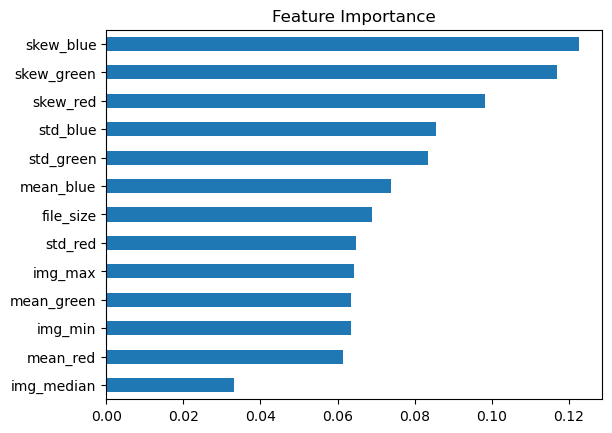

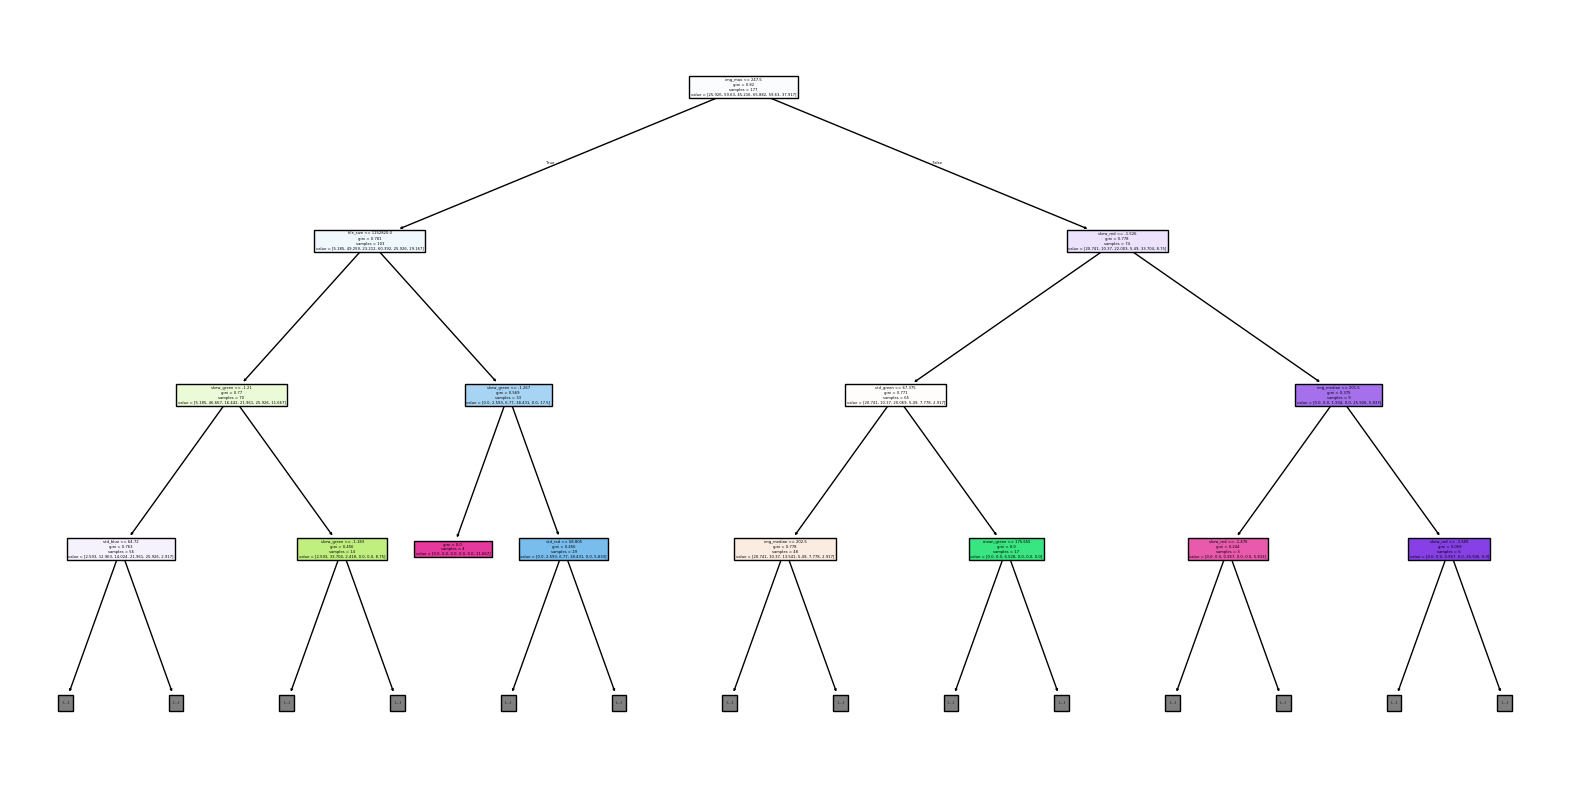

RF model Oversampling - Train and Predict
Accuracy of train data:  1.0
Accuracy of test data:  0.7183098591549296
                precision    recall  f1-score   support

         crack       0.25      0.40      0.31         5
faulty_imprint       0.50      0.50      0.50         4
          good       0.88      0.86      0.87        49
          poke       0.00      0.00      0.00         4
       scratch       0.20      0.20      0.20         5
       squeeze       1.00      1.00      1.00         4

      accuracy                           0.72        71
     macro avg       0.47      0.49      0.48        71
  weighted avg       0.72      0.72      0.72        71



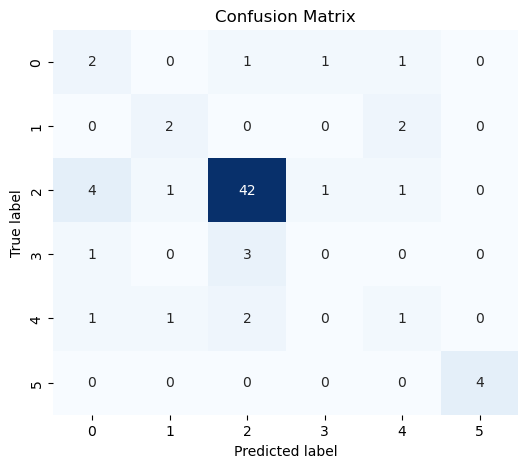

In [70]:
# Predict defect type per category
# Use 2 models KNN et RF with oversampling (Compare with and without oversampling for 2 models)
# RF Oversampling is best

#df= pd.read_pickle("mvtec_full_statistiques_features_colour_images.pkl")
filtered_df = df[df["category_name"] == "capsule"]
#print(filtered_df.head(5))

X = filtered_df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y= filtered_df['dir_name']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)

KNN_TrainAndPredict(X_train,y_train,X_test,y_test)
KNN_Oversampling_TrainAndPredict(X_train,y_train,X_test,y_test)
#SVM_TrainAndPredict(X_train,y_train,X_test,y_test)
'''
X, X_valid, y, y_valid = train_test_split(X, y, test_size=0.1 )
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
'''
rf_output = RF_TrainAndPredict(None, X_train,y_train,X_test,y_test)
#RF_TrainAndPredict(rf_output, X_train, y_train, X_valid, y_valid)
RF_Oversampling_TrainAndPredict(X_train,y_train,X_test,y_test)


In [41]:
def RF_TrainAndPredict(rf_model, X_train,y_train,X_test,y_test):
    if (rf_model is None):
        print('Creating Random forest model and train. Predict with test data')
        rf = RandomForestClassifier(n_jobs=-1, random_state=42)
        #rf = RandomForestClassifier(n_jobs=-1, random_state=42, class_weight="balanced")
        rf.fit(X_train, y_train)
        print('Accuracy of train data: ', rf.score(X_train, y_train))
    else:
        print('Using existing random forest model, predict with validation data')
        rf = rf_model
    y_pred = rf.predict(X_test)
    print('Accuracy of test data: ', accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    cm= confusion_matrix(y_test,y_pred)
    displayheatmap(cm)
    
    importances = rf.feature_importances_

    print("Significant features impacting prediction")
    feat_imp = pd.Series(importances, index=X_train.columns)
    feat_imp = feat_imp.sort_values(ascending=False)
    print(feat_imp)

    feat_imp.head(15).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title("Feature Importance")
    plt.show()

    tree = rf.estimators_[0]   # first tree
    
    plt.figure(figsize=(20, 10))
    plot_tree(
        tree,
        feature_names=X_train.columns,
        filled=True,
        max_depth=3   # limit depth to keep it readable
    )
    plt.show()

    #print('Predicted target values: ', y_pred)
    return rf

In [58]:
def RF_Oversampling_TrainAndPredict(X_train,y_train,X_test,y_test):
    print('RF model Oversampling - Train and Predict')
    pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(n_jobs=-1, random_state=42))
    ])
    pipeline.fit(X_train, y_train)
    print('Accuracy of train data: ', pipeline.score(X_train, y_train))
    y_pred = pipeline.predict(X_test)
    print('Accuracy of test data: ', accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    #print(classification_report_imbalanced(y_test, y_pred))
    cm= confusion_matrix(y_test,y_pred)
    displayheatmap(cm)

In [30]:
def KNN_TrainAndPredict(X_train,y_train,X_test,y_test):
    print('KNN model - Train and predict')
    knn = KNeighborsClassifier()
    knn.fit(X_train, y_train)
    print('Accuracy of train data: ', knn.score(X_train, y_train))
    y_pred = knn.predict(X_test)
    print('Accuracy of test data: ', accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    #print(classification_report_imbalanced(y_test, y_pred))
    cm= confusion_matrix(y_test,y_pred)
    displayheatmap(cm)

In [36]:
def KNN_Oversampling_TrainAndPredict(X_train,y_train,X_test,y_test):
    print('KNN model Oversampling - Train and Predict')
    pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(k_neighbors=5)),
    ("knn", KNeighborsClassifier(n_neighbors=7, weights="distance"))
    ])
    pipeline.fit(X_train, y_train)
    print('Accuracy of train data: ', pipeline.score(X_train, y_train))
    y_pred = pipeline.predict(X_test)
    print('Accuracy of test data: ', accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    #print(classification_report_imbalanced(y_test, y_pred))
    cm= confusion_matrix(y_test,y_pred)
    displayheatmap(cm)

In [9]:
def SVM_TrainAndPredict(X_train,y_train,X_test,y_test):
    print('SVM model - Train and predict')
    svm = SVC()
    svm.fit(X_train, y_train)
    print('Accuracy of train data: ', svm.score(X_train, y_train))
    y_pred = svm.predict(X_test)
    print('Accuracy of test data: ',accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    cm= confusion_matrix(y_test,y_pred)
    displayheatmap(cm)

(5354, 22)
[ 8  5  7 ...  3 11 14]
['bottle' 'cable' 'capsule' 'carpet' 'grid' 'hazelnut' 'leather'
 'metal_nut' 'pill' 'screw' 'tile' 'toothbrush' 'transistor' 'wood'
 'zipper']
[0]	train-mlogloss:2.63336	eval-mlogloss:2.63415
[1]	train-mlogloss:2.56723	eval-mlogloss:2.56840
[2]	train-mlogloss:2.50531	eval-mlogloss:2.50686
[3]	train-mlogloss:2.44694	eval-mlogloss:2.44886
[4]	train-mlogloss:2.39185	eval-mlogloss:2.39406
[5]	train-mlogloss:2.33969	eval-mlogloss:2.34218
[6]	train-mlogloss:2.29014	eval-mlogloss:2.29296
[7]	train-mlogloss:2.24297	eval-mlogloss:2.24613
[8]	train-mlogloss:2.19797	eval-mlogloss:2.20148
[9]	train-mlogloss:2.15495	eval-mlogloss:2.15875
[10]	train-mlogloss:2.11374	eval-mlogloss:2.11783
[11]	train-mlogloss:2.07417	eval-mlogloss:2.07861
[12]	train-mlogloss:2.03613	eval-mlogloss:2.04081
[13]	train-mlogloss:1.99947	eval-mlogloss:2.00437
[14]	train-mlogloss:1.96416	eval-mlogloss:1.96928
[15]	train-mlogloss:1.93009	eval-mlogloss:1.93547
[16]	train-mlogloss:1.89720	eva

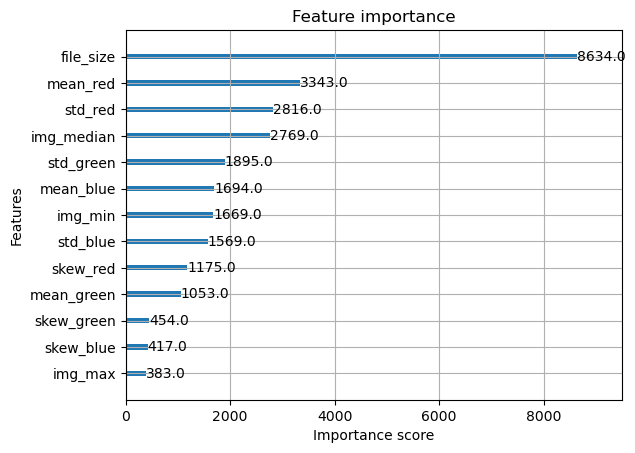

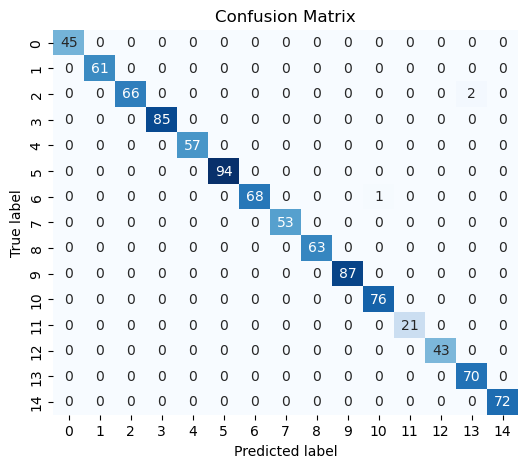

'[0]\teval-mlogloss:0.01526475845980052'

In [103]:
# XG Boost - Predict classes
df = pd.read_pickle("mvtec_full_statistiques_features.pkl")

print(df.shape)
X = df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y_cat= df['category_name']
le = LabelEncoder()
y = le.fit_transform(y_cat)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)
print(y_train)
print(le.classes_)

X, X_valid, y, y_valid = train_test_split(X, y, test_size=0.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
train = xgb.DMatrix(data=X_train, label=y_train)
test = xgb.DMatrix(data=X_test, label=y_test)
valid = xgb.DMatrix(data=X_valid, label=y_valid)

#params = {'booster': 'gbtree', 'learning_rate': 1, 'objective': 'multi:softprob'}

#xgb1 = xgb.train(params=params, dtrain=train, num_boost_round=100, evals=[(train, 'train'), (test, 'eval')])

params = {'booster': 'gbtree', 'learning_rate': 0.01, 'objective': 'multi:softprob',  'num_class' :15}

xgb2 = xgb.train(params=params, dtrain=train, num_boost_round=700, evals=[(train, 'train'), (test, 'eval')])

xgb.plot_importance(xgb2, max_num_features=15);

#types= ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

#for f in types:
#    xgb.plot_importance(xgb2 ,max_num_features=15, importance_type=f, title='importance: '+f);

bst_cv = xgb.cv(params=params,
                dtrain=train,
                num_boost_round=100,
                nfold=3,
                early_stopping_rounds=60)
print('Best CV: ',bst_cv)

preds = xgb2.predict(test)
xgbpreds = np.argmax(preds, axis=1)
pd.crosstab(xgbpreds, pd.Series(y_test))

#y_pred = xgb2.predict(test)
print(accuracy_score(pd.Series(y_test), xgbpreds))
print(classification_report(pd.Series(y_test), xgbpreds))
cm= confusion_matrix(pd.Series(y_test),xgbpreds)
displayheatmap(cm)

xgb2.eval(test)


(5354, 22)
[0]	train-logloss:0.41832	eval-logloss:0.49051
[1]	train-logloss:0.35260	eval-logloss:0.43298
[2]	train-logloss:0.30539	eval-logloss:0.40947
[3]	train-logloss:0.28263	eval-logloss:0.40594
[4]	train-logloss:0.26050	eval-logloss:0.39707
[5]	train-logloss:0.24049	eval-logloss:0.38352
[6]	train-logloss:0.22223	eval-logloss:0.37941
[7]	train-logloss:0.21086	eval-logloss:0.37821
[8]	train-logloss:0.19951	eval-logloss:0.38126
[9]	train-logloss:0.18950	eval-logloss:0.37592
[10]	train-logloss:0.17537	eval-logloss:0.38174
[11]	train-logloss:0.16031	eval-logloss:0.38003
[12]	train-logloss:0.14910	eval-logloss:0.37226
[13]	train-logloss:0.14227	eval-logloss:0.37424
[14]	train-logloss:0.13533	eval-logloss:0.37736
[15]	train-logloss:0.12609	eval-logloss:0.37156
[16]	train-logloss:0.12134	eval-logloss:0.37463
[17]	train-logloss:0.11191	eval-logloss:0.37703
[18]	train-logloss:0.11064	eval-logloss:0.37606
[19]	train-logloss:0.10351	eval-logloss:0.37831
[20]	train-logloss:0.09906	eval-logloss

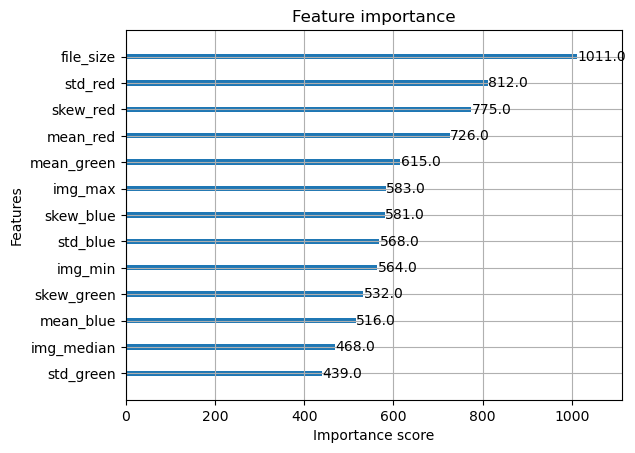

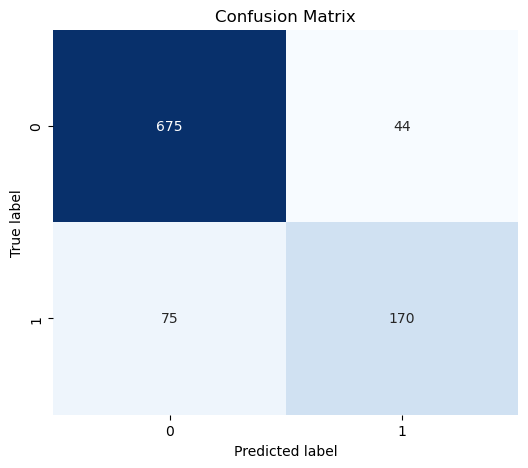

'[0]\teval-logloss:0.52341836017386401'

In [104]:
# XG Boost - Predict anamoly
#df= pd.read_pickle("mvtec_full_statistiques_features.pkl")
print(df.shape)

X = df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y= df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)
X, X_valid, y, y_valid = train_test_split(X, y, test_size=0.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
train = xgb.DMatrix(data=X_train, label=y_train)
test = xgb.DMatrix(data=X_test, label=y_test)
valid = xgb.DMatrix(data=X_valid, label=y_valid)
params = {'booster': 'gbtree', 'learning_rate': 1, 'objective': 'binary:logistic'}

#xgb1 = xgb.train(params=params, dtrain=train, num_boost_round=100, evals=[(train, 'train'), (test, 'eval')])

#params = {'booster': 'gbtree', 'learning_rate': 0.01, 'objective': 'binary:logistic'}

xgb2 = xgb.train(params=params, dtrain=train, num_boost_round=700, evals=[(train, 'train'), (test, 'eval')])

xgb.plot_importance(xgb2, max_num_features=15);

types= ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

#for f in types:
#    xgb.plot_importance(xgb2 ,max_num_features=15, importance_type=f, title='importance: '+f);

bst_cv = xgb.cv(params=params,
                dtrain=train,
                num_boost_round=100,
                nfold=3,
                early_stopping_rounds=60)
bst_cv

preds = xgb2.predict(test)
xgbpreds = pd.Series(np.where(preds > 0.5, 1, 0))
pd.crosstab(xgbpreds, pd.Series(y_test))

#y_pred = xgb2.predict(test)
print(accuracy_score(pd.Series(y_test), xgbpreds))
print(classification_report(pd.Series(y_test), xgbpreds))
cm= confusion_matrix(pd.Series(y_test),xgbpreds)
displayheatmap(cm)

xgb2.eval(test)


In [55]:
# How SMOTE works
from imblearn.over_sampling import SMOTE
from collections import Counter

filtered_df = df[df["category_name"] == "leather"]

X = filtered_df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y= filtered_df['dir_name']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before:", Counter(y))
print("After :", Counter(y_resampled))

Before: Counter({'good': 277, 'color': 19, 'cut': 19, 'glue': 19, 'poke': 18, 'fold': 17})
After : Counter({'color': 277, 'cut': 277, 'fold': 277, 'glue': 277, 'good': 277, 'poke': 277})
